## Install Dependencies

In [ ]:
!pip install tslearn umap-learn yfinance hmmlearn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.7/401.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 18.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.66.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.


## Imports & Configuration

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
import itertools
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score)
from sklearn.manifold import TSNE
from hmmlearn.hmm import GaussianHMM
import umap

from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Data Download & Feature Engineering

In [ ]:
def download_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    data = yf.download(ticker, start=start, end=end, auto_adjust=True)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.droplevel(1)
    return data


def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    4-feature set, all computed without lookahead.

    Features:
      - log_return          : daily log return (rolling-standardised)
      - intraday_range      : (high-low)/close (rolling-standardised)
      - volume_z            : volume Z-score, 20-day rolling
      - log_realised_vol    : log of 20-day realised volatility (level feature,
                              normalised against full training-fold history at
                              fit time to preserve volatility-level signal —
                              addresses Reviewer §5.5)
    """
    df = pd.DataFrame(index=data.index)
    close = data["Close"]
    high, low = data["High"], data["Low"]
    vol = data["Volume"]

    log_ret = np.log(close / close.shift(1))

    df["log_return"]       = log_ret
    df["intraday_range"]   = (high - low) / close

    vol_ma  = vol.rolling(20).mean()
    vol_std = vol.rolling(20).std()
    df["volume_z"]         = (vol - vol_ma) / (vol_std + 1e-9)

    # 20-day realised volatility (annualised log scale)
    realised_vol = log_ret.rolling(20).std() * np.sqrt(252)
    df["log_realised_vol"] = np.log(realised_vol + 1e-9)

    df.dropna(inplace=True)
    return df


TICKER     = "^GSPC"
START_DATE = "1993-01-01"
END_DATE   = "2026-01-01"

raw_data   = download_data(TICKER, START_DATE, END_DATE)
feature_df = engineer_features(raw_data)

print(f"Raw data shape        : {raw_data.shape}")
print(f"Feature matrix shape  : {feature_df.shape}")
print(f"Features ({len(feature_df.columns)}): {list(feature_df.columns)}")
print(f"Date range            : {feature_df.index[0].date()} → {feature_df.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Raw data shape        : (8307, 5)
Feature matrix shape  : (8287, 4)
Features (4): ['log_return', 'intraday_range', 'volume_z', 'log_realised_vol']
Date range            : 1993-02-01 → 2025-12-31


## Rolling Z-Score Normalisation

In [ ]:
ROLLING_WINDOW = 252  # trading days

def rolling_zscore_normalise(df: pd.DataFrame, window: int = 252) -> pd.DataFrame:
    """
    Apply rolling Z-score normalisation per feature using only past data.
    The log_realised_vol column is kept in log-level space and is NOT
    rolling-standardised here; it will be standardised against the
    training-fold statistics at split time to preserve level information.
    """
    out = pd.DataFrame(index=df.index)
    standardise_cols = ["log_return", "intraday_range", "volume_z"]
    level_cols       = ["log_realised_vol"]

    for col in standardise_cols:
        mu    = df[col].rolling(window, min_periods=window).mean()
        sigma = df[col].rolling(window, min_periods=window).std()
        out[col] = (df[col] - mu) / (sigma + 1e-9)

    for col in level_cols:
        out[col] = df[col]   # kept as level; standardised at split time

    return out.dropna()


normalised_df = rolling_zscore_normalise(feature_df, window=ROLLING_WINDOW)
print(f"Normalised feature matrix: {normalised_df.shape}")
print(f"Date range after burn-in : {normalised_df.index[0].date()} → {normalised_df.index[-1].date()}")

Normalised feature matrix: (8036, 4)
Date range after burn-in : 1994-01-27 → 2025-12-31


## Walk-Forward Split with Embargo

In [ ]:
def walk_forward_splits(df: pd.DataFrame,
                        train_years: int  = 10,
                        val_years: int    = 5,
                        test_years: int   = 3,
                        embargo_days: int = 60):
    """
    Yields (train_df, val_df, test_df) with an embargo gap of `embargo_days`
    at each boundary to prevent leakage from overlapping windows and the
    252-day normalisation lookback (Reviewer §5.3).

    embargo_days should be >= window_size; set to 60 as a conservative default
    that covers the largest window size in the hyperparameter grid.
    """
    total_days = len(df)
    idx        = df.index

    train_size = int(252 * train_years)
    val_size   = int(252 * val_years)
    test_size  = int(252 * test_years)
    step_size  = test_size

    start = 0
    splits = []
    while start + train_size + embargo_days + val_size + embargo_days + test_size <= total_days:
        t_end  = start + train_size
        v_start = t_end  + embargo_days
        v_end   = v_start + val_size
        te_start = v_end  + embargo_days
        te_end   = te_start + test_size

        splits.append((
            df.iloc[start:t_end],
            df.iloc[v_start:v_end],
            df.iloc[te_start:te_end]
        ))
        start += step_size

    return splits


splits = walk_forward_splits(normalised_df)
print(f"Number of walk-forward folds: {len(splits)}")
for i, (tr, va, te) in enumerate(splits):
    print(f"  Fold {i+1}: train {tr.index[0].date()}→{tr.index[-1].date()} | "
          f"val {va.index[0].date()}→{va.index[-1].date()} | "
          f"test {te.index[0].date()}→{te.index[-1].date()}")

Number of walk-forward folds: 5
  Fold 1: train 1994-01-27→2004-01-29 | val 2004-04-27→2009-04-28 | test 2009-07-24→2012-07-23
  Fold 2: train 1997-01-24→2007-01-31 | val 2007-04-30→2012-04-26 | test 2012-07-24→2015-07-27
  Fold 3: train 2000-01-25→2010-02-01 | val 2010-04-29→2015-04-30 | test 2015-07-28→2018-07-26
  Fold 4: train 2003-01-30→2013-02-01 | val 2013-05-01→2018-05-01 | test 2018-07-27→2021-07-28
  Fold 5: train 2006-01-31→2016-02-03 | val 2016-05-02→2021-05-03 | test 2021-07-29→2024-07-31


## Sliding-Window Builder

In [ ]:
def build_sliding_windows(df: pd.DataFrame,
                          window_size: int,
                          level_col: str = "log_realised_vol",
                          level_scaler=None,
                          fit_level_scaler: bool = True):
    """
    Build overlapping windows.  The level feature (log_realised_vol) is
    standardised here against training-fold statistics only, so its level
    information is preserved relative to the training distribution while
    still being on a comparable scale to other features (Reviewer §5.5).
    """
    values = df.values.astype(np.float32)

    # Standardise the level column against fold statistics
    level_idx = list(df.columns).index(level_col)
    if fit_level_scaler:
        level_mean  = values[:, level_idx].mean()
        level_std   = values[:, level_idx].std() + 1e-9
        level_scaler = (level_mean, level_std)
    if level_scaler is not None:
        values[:, level_idx] = (values[:, level_idx] - level_scaler[0]) / level_scaler[1]

    windows, dates = [], []
    for i in range(len(values) - window_size):
        windows.append(values[i: i + window_size])
        dates.append(df.index[i + window_size - 1])   # label at window END (§5.9)

    X = torch.tensor(np.array(windows, dtype=np.float32))
    return X, level_scaler, pd.DatetimeIndex(dates)


# Default dataset using full normalised_df for ablation studies
WINDOW_SIZE = 20
X_tensor, level_scaler_default, window_dates = build_sliding_windows(
    normalised_df, WINDOW_SIZE, fit_level_scaler=True
)
INPUT_DIM = X_tensor.shape[2]

print(f"Default tensor : {X_tensor.shape}  (samples × days × features)")
print(f"Input dim      : {INPUT_DIM}")

Default tensor : torch.Size([8016, 20, 4])  (samples × days × features)
Input dim      : 4


## Model Architecture

In [ ]:
class TemporalAutoencoder(nn.Module):
    """
    Stacked RNN (LSTM or GRU) autoencoder with temporal attention pooling.

    LayerNorm is used instead of BatchNorm1d between recurrent layers —
    BatchNorm is known to interfere with RNN hidden-state dynamics
    (Reviewer §5.8; Ba et al. 2016).
    """

    def __init__(self, input_dim, hidden_dim, latent_dim,
                 num_layers=2, dropout=0.2, rnn_type="LSTM"):
        super().__init__()
        rnn_cls  = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        drop     = dropout if num_layers > 1 else 0.0

        self.encoder    = rnn_cls(input_dim, hidden_dim, num_layers,
                                  batch_first=True, dropout=drop)
        self.attn_proj  = nn.Linear(hidden_dim, 1)
        self.to_latent  = nn.Linear(hidden_dim, latent_dim)
        self.ln_latent  = nn.LayerNorm(latent_dim)   # LayerNorm replaces BatchNorm
        self.from_latent = nn.Linear(latent_dim, hidden_dim)
        self.decoder    = rnn_cls(hidden_dim, hidden_dim, num_layers,
                                  batch_first=True, dropout=drop)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        enc_out, _ = self.encoder(x)
        attn_w     = torch.softmax(self.attn_proj(enc_out), dim=1)
        context    = (attn_w * enc_out).sum(dim=1)
        return self.ln_latent(self.to_latent(context))

    def decode(self, latent, seq_len):
        z   = self.from_latent(latent).unsqueeze(1).repeat(1, seq_len, 1)
        out, _ = self.decoder(z)
        return self.output_layer(out)

    def forward(self, x):
        latent = self.encode(x)
        return latent, self.decode(latent, x.size(1))


class ClusteringLayer(nn.Module):
    """Student's t-distribution soft assignment (DEC)."""

    def __init__(self, num_clusters, latent_dim, alpha=1.0):
        super().__init__()
        self.alpha    = alpha
        self.clusters = nn.Parameter(torch.Tensor(num_clusters, latent_dim))
        nn.init.xavier_uniform_(self.clusters)

    def forward(self, z):
        norm_sq = torch.sum((z.unsqueeze(1) - self.clusters) ** 2, dim=2)
        q       = (1.0 + norm_sq / self.alpha).pow(-(self.alpha + 1.0) / 2.0)
        return (q.t() / q.sum(dim=1)).t()


class DeepRegimeNet(nn.Module):

    def __init__(self, input_dim, hidden_dim, latent_dim, num_clusters,
                 num_layers=2, dropout=0.2, rnn_type="LSTM"):
        super().__init__()
        self.ae         = TemporalAutoencoder(input_dim, hidden_dim, latent_dim,
                                              num_layers, dropout, rnn_type)
        self.clustering = ClusteringLayer(num_clusters, latent_dim)

    def forward(self, x):
        latent, recon = self.ae(x)
        q             = self.clustering(latent)
        return recon, q, latent


def build_model(input_dim, hidden_dim, latent_dim, num_clusters,
                num_layers=2, dropout=0.2, rnn_type="LSTM"):
    return DeepRegimeNet(input_dim, hidden_dim, latent_dim, num_clusters,
                         num_layers, dropout, rnn_type).to(DEVICE)

## Training Functions with Dynamic λ Annealing

In [ ]:
def calculate_target_distribution(q):
    weight = q ** 2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()


def pretrain(model, loader, epochs=60, lr=1e-3, verbose=False):
    """Phase I: reconstruction-only pre-training."""
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    mse = nn.MSELoss()
    model.train()
    history = []

    for epoch in range(epochs):
        total = 0.0
        for (x,) in loader:
            x = x.to(DEVICE)
            opt.zero_grad()
            recon, _, _ = model(x)
            loss = mse(recon, x)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item()
        avg = total / len(loader)
        history.append(avg)
        sch.step()
        if verbose and (epoch % 20 == 0 or epoch == epochs - 1):
            print(f"  Pre-train epoch {epoch:>3}  loss={avg:.5f}")
    return history


def init_centroids(model, loader):
    """Phase II initialisation: K-Means on pre-trained latent codes."""
    model.eval()
    latents = []
    with torch.no_grad():
        for (x,) in loader:
            _, _, z = model(x.to(DEVICE))
            latents.append(z.cpu().numpy())
    Z  = np.concatenate(latents)
    km = KMeans(n_clusters=model.clustering.clusters.shape[0],
                n_init=20, random_state=RANDOM_SEED)
    km.fit(Z)
    model.clustering.clusters.data = torch.tensor(
        km.cluster_centers_, dtype=torch.float32).to(DEVICE)
    return km.inertia_


def joint_train(model, loader, epochs=120, lr=5e-4,
                lam_target=0.1, update_interval=5, verbose=False):
    """
    Phase III: joint reconstruction + clustering optimisation.

    λ is linearly annealed from 0 → lam_target over the first half of
    training to allow the latent space to stabilise before the clustering
    penalty dominates (Reviewer §2 dynamic annealing suggestion).
    """
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    sch = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    mse = nn.MSELoss()
    kl  = nn.KLDivLoss(reduction="batchmean")
    model.train()
    p_batches = None
    history   = []

    warmup_epochs = epochs // 2  # linear λ warmup over first half

    for epoch in range(epochs):
        lam = lam_target * min(1.0, epoch / max(warmup_epochs, 1))

        if epoch % update_interval == 0:
            model.eval()
            all_q = []
            with torch.no_grad():
                for (x,) in loader:
                    _, q, _ = model(x.to(DEVICE))
                    all_q.append(q)
            p_full    = calculate_target_distribution(torch.cat(all_q))
            p_batches = list(torch.split(p_full, loader.batch_size))
            model.train()

        total = 0.0
        for i, (x,) in enumerate(loader):
            if i >= len(p_batches):
                continue
            x, tp = x.to(DEVICE), p_batches[i].to(DEVICE)
            opt.zero_grad()
            recon, q, _ = model(x)
            loss = mse(recon, x) + lam * kl(q.clamp(1e-10).log(), tp.clamp(1e-10))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item()

        avg = total / len(loader)
        history.append(avg)
        sch.step()
        if verbose and (epoch % 30 == 0 or epoch == epochs - 1):
            print(f"  Joint epoch {epoch:>3}  loss={avg:.5f}  λ={lam:.4f}")
    return history


def get_outputs(model, loader):
    """Extract latent vectors, reconstructions, hard labels, and inputs."""
    model.eval()
    Z, R, L, X = [], [], [], []
    with torch.no_grad():
        for (x,) in loader:
            x = x.to(DEVICE)
            recon, q, z = model(x)
            Z.append(z.cpu().numpy())
            R.append(recon.cpu().numpy())
            L.append(torch.argmax(q, dim=1).cpu().numpy())
            X.append(x.cpu().numpy())
    return (np.concatenate(Z), np.concatenate(R),
            np.concatenate(L), np.concatenate(X))


def clustering_score(latents, labels):
    """Composite internal score (secondary metric only — Reviewer §5.2)."""
    if len(np.unique(labels)) < 2:
        return -np.inf
    sil = silhouette_score(latents, labels)
    dbi = davies_bouldin_score(latents, labels)
    chi = calinski_harabasz_score(latents, labels)
    return sil - 0.1 * dbi + 0.0001 * chi


def full_train_pipeline(model, loader, pretrain_epochs=60, joint_epochs=120,
                        lam_target=0.1, verbose=False):
    pt = pretrain(model, loader, epochs=pretrain_epochs, verbose=verbose)
    _  = init_centroids(model, loader)
    jt = joint_train(model, loader, epochs=joint_epochs,
                     lam_target=lam_target, verbose=verbose)
    return pt, jt

## λ/K Selection via Reconstruction Loss

In [ ]:
def select_hyperparams_by_recon(input_dim, loader, eval_loader,
                                 lam_grid, K_grid, best_rnn,
                                 best_num_layers, best_hidden_dim,
                                 best_latent_dim, best_dropout):
    """
    Select λ and K using reconstruction loss on a held-out fold — NOT using
    the same clustering indices that will be used for final evaluation.
    This breaks the circular evaluation identified in Reviewer §S1/§5.2.
    """
    mse_fn  = nn.MSELoss()
    results = {}

    for lam in lam_grid:
        for K in K_grid:
            torch.manual_seed(RANDOM_SEED)
            m = build_model(input_dim, best_hidden_dim, best_latent_dim, K,
                            num_layers=best_num_layers, dropout=best_dropout,
                            rnn_type=best_rnn)
            full_train_pipeline(m, loader, pretrain_epochs=40,
                                joint_epochs=60, lam_target=lam)
            m.eval()
            recon_losses = []
            with torch.no_grad():
                for (x,) in eval_loader:
                    x = x.to(DEVICE)
                    recon, _, _ = m(x)
                    recon_losses.append(mse_fn(recon, x).item())
            results[(lam, K)] = np.mean(recon_losses)
            print(f"  λ={lam:<5}  K={K}  recon_loss={results[(lam,K)]:.5f}")

    best = min(results, key=results.get)
    print(f"\n  → Best (λ={best[0]}, K={best[1]}) by reconstruction loss: {results[best]:.5f}")
    return best[0], best[1]

## Ablation Study A — RNN Type (LSTM vs GRU)

In [ ]:
print("=" * 60)
print(" ABLATION A: LSTM vs GRU")
print("=" * 60)

ABLATION_LOADER = DataLoader(TensorDataset(X_tensor), batch_size=128,
                             shuffle=True, drop_last=False)
EVAL_LOADER     = DataLoader(TensorDataset(X_tensor), batch_size=128,
                             shuffle=False)

rnn_results = {}
for rnn_type in ["LSTM", "GRU"]:
    torch.manual_seed(RANDOM_SEED)
    m  = build_model(INPUT_DIM, 64, 64, 3, num_layers=2,
                     dropout=0.2, rnn_type=rnn_type)
    t0 = time.time()
    full_train_pipeline(m, ABLATION_LOADER, pretrain_epochs=50, joint_epochs=80)
    elapsed = time.time() - t0
    Z, R, L, Xi = get_outputs(m, EVAL_LOADER)

    # Check if we have more than 1 cluster to avoid ValueError in metrics
    unique_labels = np.unique(L)
    if len(unique_labels) > 1:
        sil = silhouette_score(Z, L)
        dbi = davies_bouldin_score(Z, L)
        chi = calinski_harabasz_score(Z, L)
    else:
        sil, dbi, chi = -1.0, 999.0, 0.0
        print(f"  Warning: {rnn_type} collapsed to a single cluster.")

    rnn_results[rnn_type] = dict(sil=sil, dbi=dbi, chi=chi,
                                 time=elapsed, latents=Z, labels=L)
    print(f"  {rnn_type:<6}  Sil={sil:+.4f}  DBI={dbi:.4f}  "
          f"CHI={chi:.1f}  t={elapsed:.0f}s")

best_rnn = max(rnn_results, key=lambda k: rnn_results[k]["sil"])
print(f"\n  → Best RNN type: {best_rnn}")

 ABLATION A: LSTM vs GRU
  LSTM    Sil=+0.5446  DBI=1.5104  CHI=84.1  t=74s
  GRU     Sil=-1.0000  DBI=999.0000  CHI=0.0  t=78s

  → Best RNN type: LSTM


## Ablation Study B — Effect of λ

In [ ]:
print("=" * 60)
print(" ABLATION B: Effect of λ on Joint Loss")
print("=" * 60)

lambda_grid    = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
lambda_results = {}

for lam in lambda_grid:
    torch.manual_seed(RANDOM_SEED)
    m = build_model(INPUT_DIM, 64, 64, 3, num_layers=2,
                    dropout=0.2, rnn_type=best_rnn)
    full_train_pipeline(m, ABLATION_LOADER, pretrain_epochs=50,
                        joint_epochs=80, lam_target=lam)
    Z, _, L, _ = get_outputs(m, EVAL_LOADER)

    # Check if we have more than 1 cluster to avoid ValueError in metrics
    unique_labels = np.unique(L)
    if len(unique_labels) > 1:
        sil   = silhouette_score(Z, L)
        dbi   = davies_bouldin_score(Z, L)
        chi   = calinski_harabasz_score(Z, L)
        score = clustering_score(Z, L)
    else:
        sil, dbi, chi, score = -1.0, 999.0, 0.0, -999.0
        print(f"  Warning: λ={lam} collapsed to a single cluster.")

    lambda_results[lam] = dict(sil=sil, dbi=dbi, chi=chi, score=score)
    print(f"  λ={lam:<5}  Sil={sil:+.4f}  DBI={dbi:.4f}  "
          f"CHI={chi:.1f}  composite={score:.4f}")

best_lam = max(lambda_results, key=lambda k: lambda_results[k]["score"])
print(f"\n  → Best λ (ablation, secondary metric): {best_lam}")

 ABLATION B: Effect of λ on Joint Loss
  λ=0.01   Sil=+0.1804  DBI=2.0124  CHI=654.8  composite=0.0447
  λ=0.05   Sil=+0.3980  DBI=1.5157  CHI=193.8  composite=0.2658
  λ=0.1    Sil=+0.5446  DBI=1.5104  CHI=84.1  composite=0.4019
  λ=0.2    Sil=-1.0000  DBI=999.0000  CHI=0.0  composite=-999.0000
  λ=0.5    Sil=-1.0000  DBI=999.0000  CHI=0.0  composite=-999.0000
  λ=1.0    Sil=-1.0000  DBI=999.0000  CHI=0.0  composite=-999.0000

  → Best λ (ablation, secondary metric): 0.1


## Ablation Study C — Effect of K

In [ ]:
print("=" * 60)
print(" ABLATION C: Effect of K (number of regimes)")
print("=" * 60)

K_grid    = [2, 3, 4, 5, 6]
K_results = {}

for K in K_grid:
    torch.manual_seed(RANDOM_SEED)
    m = build_model(INPUT_DIM, 64, 64, K, num_layers=2,
                    dropout=0.2, rnn_type=best_rnn)
    full_train_pipeline(m, ABLATION_LOADER, pretrain_epochs=50,
                        joint_epochs=80, lam_target=best_lam)
    Z, _, L, _ = get_outputs(m, EVAL_LOADER)

    # Check if we have more than 1 cluster to avoid ValueError in metrics
    unique_labels = np.unique(L)
    if len(unique_labels) > 1:
        sil   = silhouette_score(Z, L)
        dbi   = davies_bouldin_score(Z, L)
        chi   = calinski_harabasz_score(Z, L)
        score = clustering_score(Z, L)
    else:
        sil, dbi, chi, score = -1.0, 999.0, 0.0, -999.0
        print(f"  Warning: K={K} collapsed to a single cluster.")

    K_results[K] = dict(sil=sil, dbi=dbi, chi=chi, score=score)
    print(f"  K={K:<2}  Sil={sil:+.4f}  DBI={dbi:.4f}  "
          f"CHI={chi:.1f}  composite={score:.4f}")

best_K = max(K_results, key=lambda k: K_results[k]["score"])
print(f"\n  → Best K (ablation, secondary metric): {best_K}")

 ABLATION C: Effect of K (number of regimes)
  K=2   Sil=-1.0000  DBI=999.0000  CHI=0.0  composite=-999.0000
  K=3   Sil=+0.5446  DBI=1.5104  CHI=84.1  composite=0.4019
  K=4   Sil=+0.6259  DBI=0.2680  CHI=12.5  composite=0.6004
  K=5   Sil=-1.0000  DBI=999.0000  CHI=0.0  composite=-999.0000
  K=6   Sil=-1.0000  DBI=999.0000  CHI=0.0  composite=-999.0000

  → Best K (ablation, secondary metric): 4


## Ablation Study D — Joint vs Sequential Training

In [ ]:
print("=" * 60)
print(" ABLATION D: Joint vs Sequential Training")
print("=" * 60)

# Sequential: pretrain AE only, then standalone K-Means
# (removes joint optimisation, keeps temporal feature learning — correct ablation)
torch.manual_seed(RANDOM_SEED)
m_seq = build_model(INPUT_DIM, 64, 64, best_K, num_layers=2,
                    dropout=0.2, rnn_type=best_rnn)
pretrain(m_seq, ABLATION_LOADER, epochs=60, verbose=False)

m_seq.eval()
ae_latents_seq = []
with torch.no_grad():
    for (x,) in EVAL_LOADER:
        z, _ = m_seq.ae(x.to(DEVICE))
        ae_latents_seq.append(z.cpu().numpy())
ae_latents_seq = np.concatenate(ae_latents_seq)
km_seq_labels  = KMeans(n_clusters=best_K, n_init=20,
                        random_state=RANDOM_SEED).fit_predict(ae_latents_seq)

sil_seq = silhouette_score(ae_latents_seq, km_seq_labels)
dbi_seq = davies_bouldin_score(ae_latents_seq, km_seq_labels)
chi_seq = calinski_harabasz_score(ae_latents_seq, km_seq_labels)

# Joint: full pipeline
torch.manual_seed(RANDOM_SEED)
m_jnt = build_model(INPUT_DIM, 128, 32, best_K, num_layers=2,
                    dropout=0.2, rnn_type=best_rnn)
full_train_pipeline(m_jnt, ABLATION_LOADER, pretrain_epochs=60,
                    joint_epochs=120, lam_target=best_lam)
Z_jnt, _, L_jnt, _ = get_outputs(m_jnt, EVAL_LOADER)
sil_jnt = silhouette_score(Z_jnt, L_jnt)
dbi_jnt = davies_bouldin_score(Z_jnt, L_jnt)
chi_jnt = calinski_harabasz_score(Z_jnt, L_jnt)

print(f"  Sequential AE + KMeans : Sil={sil_seq:+.4f}  DBI={dbi_seq:.4f}  CHI={chi_seq:.1f}")
print(f"  Joint (DeepRegimeNet)  : Sil={sil_jnt:+.4f}  DBI={dbi_jnt:.4f}  CHI={chi_jnt:.1f}")
improvement_sil = (sil_jnt - sil_seq) / (abs(sil_seq) + 1e-9) * 100
print(f"\n  → Silhouette Δ from joint training: {improvement_sil:+.1f}%")

 ABLATION D: Joint vs Sequential Training
  Sequential AE + KMeans : Sil=+0.1253  DBI=1.9503  CHI=1159.1
  Joint (DeepRegimeNet)  : Sil=+0.1046  DBI=3.8826  CHI=58.6

  → Silhouette Δ from joint training: -16.5%


## Hyperparameter Grid Search

In [ ]:
print("=" * 70)
print(" HYPERPARAMETER GRID SEARCH (Architecture)")
print(" Searching: num_layers × hidden_dim × latent_dim × window_size × dropout")
print("=" * 70)

SEARCH_GRID = {
    "num_layers": [1, 2, 3],
    "hidden_dim": [64, 128, 256],
    "latent_dim": [16, 32, 64],
    "window_w":   [20, 40, 60],
    "dropout":    [0.1, 0.2, 0.3],
}

all_combos = list(itertools.product(
    SEARCH_GRID["num_layers"], SEARCH_GRID["hidden_dim"],
    SEARCH_GRID["latent_dim"], SEARCH_GRID["window_w"],
    SEARCH_GRID["dropout"],
))

rng     = np.random.default_rng(RANDOM_SEED)
sampled = [all_combos[i] for i in rng.choice(len(all_combos), size=30, replace=False)]

print(f"  Total candidates: {len(all_combos)}   Sampled: {len(sampled)}\n")
print(f"  {'#':<4} {'layers':>7} {'hidden':>7} {'latent':>7} {'win':>5} "
      f"{'drop':>6} {'Sil':>8} {'DBI':>8} {'CHI':>8} {'recon':>8}")
print("  " + "-" * 72)

search_results = []
for idx, (nl, hd, ld, ww, dr) in enumerate(sampled):
    sc   = StandardScaler()
    Xt, ls, _ = build_sliding_windows(
        normalised_df, ww, fit_level_scaler=True)
    ldr  = DataLoader(TensorDataset(Xt), batch_size=128,
                      shuffle=True, drop_last=False)
    evl  = DataLoader(TensorDataset(Xt), batch_size=128, shuffle=False)

    torch.manual_seed(RANDOM_SEED)
    m = build_model(INPUT_DIM, hd, ld, best_K, num_layers=nl,
                    dropout=dr, rnn_type=best_rnn)
    pretrain(m, ldr, epochs=30)
    init_centroids(m, ldr)
    joint_train(m, ldr, epochs=60, lam_target=best_lam)

    Z, R, L, Xi = get_outputs(m, evl)
    mse_fn = nn.MSELoss()
    recon_loss = mse_fn(torch.tensor(R), torch.tensor(Xi)).item()

    if len(np.unique(L)) < 2:
        sil, dbi, chi = np.nan, np.nan, np.nan
    else:
        sil = silhouette_score(Z, L)
        dbi = davies_bouldin_score(Z, L)
        chi = calinski_harabasz_score(Z, L)

    search_results.append(dict(num_layers=nl, hidden_dim=hd, latent_dim=ld,
                               window_w=ww, dropout=dr, sil=sil, dbi=dbi,
                               chi=chi, recon=recon_loss))
    print(f"  {idx+1:<4} {nl:>7} {hd:>7} {ld:>7} {ww:>5} {dr:>6.1f} "
          f"{sil:>8.4f} {dbi:>8.4f} {chi:>8.1f} {recon_loss:>8.4f}")

# Sort by reconstruction loss (primary selection criterion — Reviewer §5.2)
search_df = pd.DataFrame(search_results).sort_values("recon", ascending=True)
best_cfg  = search_df.iloc[0]

print(f"\n  Best configuration (by reconstruction loss):")
print(f"  num_layers={int(best_cfg.num_layers)}, hidden_dim={int(best_cfg.hidden_dim)}, "
      f"latent_dim={int(best_cfg.latent_dim)}, window_w={int(best_cfg.window_w)}, "
      f"dropout={best_cfg.dropout:.1f}")
print(f"  Sil={best_cfg.sil:.4f}  DBI={best_cfg.dbi:.4f}  "
      f"CHI={best_cfg.chi:.1f}  recon={best_cfg.recon:.4f}")

 HYPERPARAMETER GRID SEARCH (Architecture)
 Searching: num_layers × hidden_dim × latent_dim × window_size × dropout
  Total candidates: 243   Sampled: 30

  #     layers  hidden  latent   win   drop      Sil      DBI      CHI    recon
  ------------------------------------------------------------------------
  1          2     256      64    20    0.1   0.0226   5.0741    150.4   0.2674
  2          2     128      32    20    0.1   0.0125   3.1344     48.0   0.3697
  3          2      64      32    40    0.2   0.1778   3.2689     86.4   0.5597
  4          3      64      64    60    0.3   0.0495   3.3312    645.9   0.6541
  5          1      64      64    20    0.2   0.0780   5.0798    138.5   0.4585
  6          1      64      64    40    0.1      nan      nan      nan   0.5581
  7          1     128      32    60    0.2  -0.0411   5.6632     67.4   0.5577
  8          3     128      32    20    0.1   0.1712   1.4429    123.6   0.4360
  9          3      64      64    20    0.1      n

## λ/K Final Selection via Reconstruction Loss

In [ ]:
# Use the best architecture window to build a fresh train/val split for λ/K selection
BEST_WINDOW_SEARCH = int(best_cfg.window_w)

Xt_sel, ls_sel, dates_sel = build_sliding_windows(
    normalised_df, BEST_WINDOW_SEARCH, fit_level_scaler=True)

n_total  = len(Xt_sel)
n_val    = int(n_total * 0.15)
Xt_tr    = Xt_sel[:n_total - n_val]
Xt_val   = Xt_sel[n_total - n_val:]

ldr_sel  = DataLoader(TensorDataset(Xt_tr),  batch_size=128, shuffle=True)
evl_sel  = DataLoader(TensorDataset(Xt_val), batch_size=128, shuffle=False)

print("Selecting λ and K via reconstruction loss on held-out val fold")
print("(λ/K selection decoupled from clustering evaluation — Reviewer §5.2)\n")

best_lam_final, best_K_final = select_hyperparams_by_recon(
    INPUT_DIM, ldr_sel, evl_sel,
    lam_grid=[0.01, 0.05, 0.1, 0.2],
    K_grid=[3, 4, 5, 6],
    best_rnn=best_rnn,
    best_num_layers=int(best_cfg.num_layers),
    best_hidden_dim=int(best_cfg.hidden_dim),
    best_latent_dim=int(best_cfg.latent_dim),
    best_dropout=float(best_cfg.dropout)
)

Selecting λ and K via reconstruction loss on held-out val fold
(λ/K selection decoupled from clustering evaluation — Reviewer §5.2)

  λ=0.01   K=3  recon_loss=0.50701
  λ=0.01   K=4  recon_loss=0.49891
  λ=0.01   K=5  recon_loss=0.51938
  λ=0.01   K=6  recon_loss=0.50347
  λ=0.05   K=3  recon_loss=0.50719
  λ=0.05   K=4  recon_loss=0.50054
  λ=0.05   K=5  recon_loss=0.51768
  λ=0.05   K=6  recon_loss=0.50072
  λ=0.1    K=3  recon_loss=0.50955
  λ=0.1    K=4  recon_loss=0.49855
  λ=0.1    K=5  recon_loss=0.52038
  λ=0.1    K=6  recon_loss=0.50047
  λ=0.2    K=3  recon_loss=0.50815
  λ=0.2    K=4  recon_loss=0.50092
  λ=0.2    K=5  recon_loss=0.52161
  λ=0.2    K=6  recon_loss=0.50011

  → Best (λ=0.1, K=4) by reconstruction loss: 0.49855


## Final Model Configuration & Training

In [ ]:
BEST_NUM_LAYERS = int(best_cfg.num_layers)
BEST_HIDDEN_DIM = int(best_cfg.hidden_dim)
BEST_LATENT_DIM = int(best_cfg.latent_dim)
BEST_WINDOW     = int(best_cfg.window_w)
BEST_DROPOUT    = float(best_cfg.dropout)
BEST_RNN        = best_rnn
BEST_LAM        = best_lam_final
BEST_K          = best_K_final

print("╔" + "═" * 60 + "╗")
print("║ FINAL MODEL CONFIGURATION".ljust(61) + "║")
print("╠" + "═" * 60 + "╣")
for k, v in [("RNN type",        BEST_RNN),
             ("num_layers",       BEST_NUM_LAYERS),
             ("hidden_dim",       BEST_HIDDEN_DIM),
             ("latent_dim",       BEST_LATENT_DIM),
             ("window_size",      BEST_WINDOW),
             ("dropout",          BEST_DROPOUT),
             ("λ (lambda)",       BEST_LAM),
             ("K (regimes)",      BEST_K),
             ("λ/K selected by",  "reconstruction loss (held-out val)")]:
    print(f"║  {k:<18}: {str(v):<39}║")
print("╚" + "═" * 60 + "╝")

# Rebuild dataset with best window
X_final, ls_final, window_dates = build_sliding_windows(
    normalised_df, BEST_WINDOW, fit_level_scaler=True)

final_train_loader = DataLoader(TensorDataset(X_final), batch_size=128,
                                shuffle=True, drop_last=False)
final_eval_loader  = DataLoader(TensorDataset(X_final), batch_size=128,
                                shuffle=False)
INPUT_DIM = X_final.shape[2]

torch.manual_seed(RANDOM_SEED)
final_model = build_model(INPUT_DIM, BEST_HIDDEN_DIM, BEST_LATENT_DIM, BEST_K,
                          num_layers=BEST_NUM_LAYERS, dropout=BEST_DROPOUT,
                          rnn_type=BEST_RNN)

total_params = sum(p.numel() for p in final_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")
print(final_model)
print("\nTraining final model …")

pretrain_hist = pretrain(final_model, final_train_loader,
                         epochs=80, lr=1e-3, verbose=True)
_ = init_centroids(final_model, final_train_loader)
joint_hist = joint_train(final_model, final_train_loader,
                         epochs=150, lr=5e-4,
                         lam_target=BEST_LAM, verbose=True)

print("Final model training complete.")

## Training Loss Curves

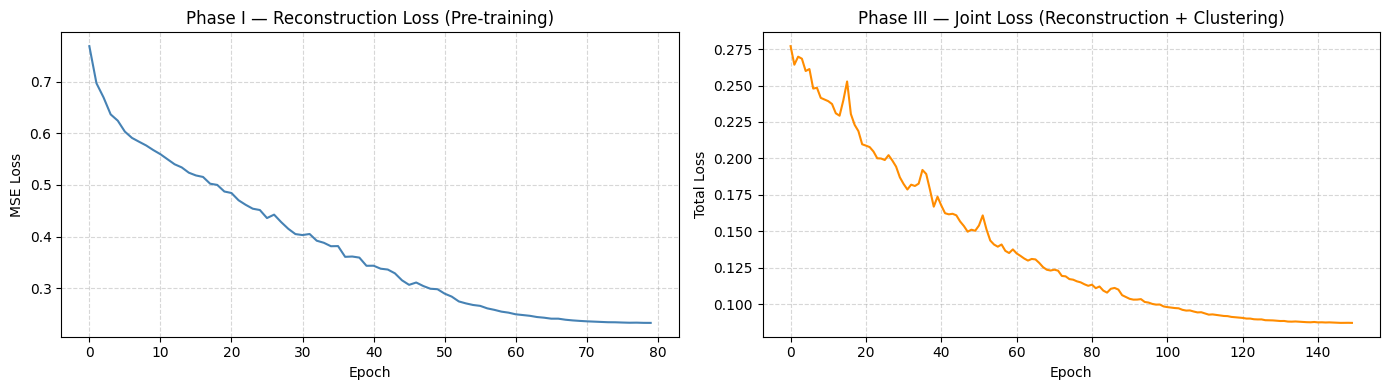

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(pretrain_hist, color="steelblue", linewidth=1.5)
axes[0].set_title("Phase I — Reconstruction Loss (Pre-training)", fontsize=12)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(joint_hist, color="darkorange", linewidth=1.5)
axes[1].set_title("Phase III — Joint Loss (Reconstruction + Clustering)", fontsize=12)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Total Loss")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("training_loss_curves.png", dpi=130, bbox_inches="tight")
plt.show()

## Extract Final Model Outputs

In [ ]:
drn_latents, drn_recon, drn_labels, drn_inputs = get_outputs(
    final_model, final_eval_loader)

# Regime series indexed at window END; trades execute at t+1 (Reviewer §5.9)
regime_series = pd.Series(drn_labels, index=window_dates, name="regime")
close_prices  = raw_data["Close"].reindex(window_dates).ffill()
palette       = sns.color_palette("tab10", BEST_K)

print(f"Latent matrix : {drn_latents.shape}")
print(f"Regime labels : {drn_labels.shape}  unique={np.unique(drn_labels)}")
print(f"Distribution  : {np.bincount(drn_labels)}")

## Baselines — DTW-KMeans, Sequential AE+KMeans, Gaussian HMM, Naïve Volatility Quantile

In [ ]:
# Baseline 1: DTW-KMeans
print("Fitting DTW-KMeans …")
X_np   = X_final.cpu().numpy()
dtw_sc = TimeSeriesScalerMeanVariance().fit_transform(X_np)
dtw_km = TimeSeriesKMeans(n_clusters=BEST_K, metric="dtw",
                          max_iter=15, random_state=RANDOM_SEED, n_jobs=-1)
dtw_labels = dtw_km.fit_predict(dtw_sc)
print(f"DTW-KMeans done.  Distribution: {np.bincount(dtw_labels)}")

Fitting DTW-KMeans …
DTW-KMeans done.  Distribution: [1536 2278 1946 2256]


In [34]:
# Baseline 2: Sequential AE + KMeans
print("\nFitting Sequential AE + KMeans …")
torch.manual_seed(RANDOM_SEED)
m_seq2 = build_model(INPUT_DIM, BEST_HIDDEN_DIM, BEST_LATENT_DIM, BEST_K,
                     num_layers=BEST_NUM_LAYERS, dropout=BEST_DROPOUT,
                     rnn_type=BEST_RNN)
pretrain(m_seq2, final_train_loader, epochs=80, lr=1e-3)

m_seq2.eval()
ae_lats, ae_recs, ae_inps = [], [], []
with torch.no_grad():
    for (x,) in final_eval_loader:
        x = x.to(DEVICE)
        z, r = m_seq2.ae(x)
        ae_lats.append(z.cpu().numpy())
        ae_recs.append(r.cpu().numpy())
        ae_inps.append(x.cpu().numpy())
ae_latents = np.concatenate(ae_lats)
ae_recon   = np.concatenate(ae_recs)
ae_inputs  = np.concatenate(ae_inps)
ae_labels  = KMeans(n_clusters=BEST_K, n_init=20,
                    random_state=RANDOM_SEED).fit_predict(ae_latents)
print(f"Sequential AE+KMeans done.  Distribution: {np.bincount(ae_labels)}")


Fitting Sequential AE + KMeans …
Sequential AE+KMeans done.  Distribution: [2104 1689 2356 1867]


In [35]:
# Baseline 3: Gaussian HMM (Reviewer §S2 / §5.1)
print("\nFitting Gaussian HMM …")
# HMM is fit on the raw (non-windowed) normalised feature matrix
hmm_features = normalised_df.reindex(window_dates).dropna().values
hmm_model    = GaussianHMM(n_components=BEST_K, covariance_type="full",
                            n_iter=200, random_state=RANDOM_SEED)
hmm_model.fit(hmm_features)
hmm_labels = hmm_model.predict(hmm_features)
print(f"Gaussian HMM done.  Distribution: {np.bincount(hmm_labels)}")
print(f"  Log-likelihood: {hmm_model.score(hmm_features):.2f}")


Fitting Gaussian HMM …
Gaussian HMM done.  Distribution: [1497 2599 1653 2267]
  Log-likelihood: -30438.16


In [36]:
# Baseline 4: Naïve Volatility Quantile (Reviewer §5.1)
print("\nFitting Naïve Volatility Quantile baseline …")
vol_series   = normalised_df["log_realised_vol"].reindex(window_dates).dropna()
quantile_labels = pd.qcut(vol_series, q=BEST_K,
                           labels=False, duplicates="drop").values
print(f"Naïve Vol Quantile done.  Distribution: {np.bincount(quantile_labels.astype(int))}")


Fitting Naïve Volatility Quantile baseline …
Naïve Vol Quantile done.  Distribution: [2004 2004 2004 2004]


## Multi-Seed Evaluation (Reviewer §2.2)

In [37]:
SEEDS = [42, 123, 456, 789, 2024]

def evaluate_multi_seed(input_dim, hidden_dim, latent_dim, K,
                        num_layers, dropout, rnn_type, lam_target,
                        train_loader, eval_loader, seeds,
                        pretrain_epochs=80, joint_epochs=150):
    """
    Run full pipeline over multiple seeds; report mean ± std of key metrics.
    Addresses Reviewer §2.2 requirement for dispersion statistics.
    """
    records = []
    for seed in seeds:
        torch.manual_seed(seed)
        np.random.seed(seed)
        m = build_model(input_dim, hidden_dim, latent_dim, K,
                        num_layers=num_layers, dropout=dropout,
                        rnn_type=rnn_type)
        full_train_pipeline(m, train_loader,
                            pretrain_epochs=pretrain_epochs,
                            joint_epochs=joint_epochs,
                            lam_target=lam_target)
        Z, R, L, Xi = get_outputs(m, eval_loader)
        mse_fn = nn.MSELoss()
        recon  = mse_fn(torch.tensor(R), torch.tensor(Xi)).item()
        sil    = silhouette_score(Z, L) if len(np.unique(L)) > 1 else np.nan
        dbi    = davies_bouldin_score(Z, L) if len(np.unique(L)) > 1 else np.nan
        chi    = calinski_harabasz_score(Z, L) if len(np.unique(L)) > 1 else np.nan
        records.append(dict(seed=seed, sil=sil, dbi=dbi, chi=chi, recon=recon))

    df_r = pd.DataFrame(records)
    print(f"\n  Multi-seed results ({len(seeds)} seeds):")
    print(f"  {'Metric':<20} {'Mean':>10} {'Std':>10}")
    print("  " + "-" * 42)
    for col in ["sil", "dbi", "chi", "recon"]:
        print(f"  {col:<20} {df_r[col].mean():>10.4f} {df_r[col].std():>10.4f}")
    return df_r


print("Running multi-seed evaluation for DeepRegimeNet …")
multiseed_df = evaluate_multi_seed(
    INPUT_DIM, BEST_HIDDEN_DIM, BEST_LATENT_DIM, BEST_K,
    BEST_NUM_LAYERS, BEST_DROPOUT, BEST_RNN, BEST_LAM,
    final_train_loader, final_eval_loader, SEEDS
)

Running multi-seed evaluation for DeepRegimeNet …

  Multi-seed results (5 seeds):
  Metric                     Mean        Std
  ------------------------------------------
  sil                      0.0148     0.0274
  dbi                      4.1719     2.2451
  chi                     65.3220    57.8662
  recon                    0.0658     0.0032


## Internal Clustering Metrics (Secondary)

In [38]:
mse_fn = nn.MSELoss()

def recon_loss(recon_np, input_np):
    return mse_fn(torch.tensor(recon_np), torch.tensor(input_np)).item()

metrics = {}
metrics["DeepRegimeNet"] = {
    "Silhouette Score":    silhouette_score(drn_latents, drn_labels),
    "Davies-Bouldin Index": davies_bouldin_score(drn_latents, drn_labels),
    "Calinski-Harabasz Idx": calinski_harabasz_score(drn_latents, drn_labels),
    "Reconstruction Loss": recon_loss(drn_recon, drn_inputs),
}
metrics["Seq AE + KMeans"] = {
    "Silhouette Score":    silhouette_score(ae_latents, ae_labels),
    "Davies-Bouldin Index": davies_bouldin_score(ae_latents, ae_labels),
    "Calinski-Harabasz Idx": calinski_harabasz_score(ae_latents, ae_labels),
    "Reconstruction Loss": recon_loss(ae_recon, ae_inputs),
}
dtw_flat = dtw_sc.reshape(dtw_sc.shape[0], -1)
metrics["DTW-KMeans"] = {
    "Silhouette Score":    silhouette_score(dtw_flat, dtw_labels),
    "Davies-Bouldin Index": davies_bouldin_score(dtw_flat, dtw_labels),
    "Calinski-Harabasz Idx": calinski_harabasz_score(dtw_flat, dtw_labels),
    "Reconstruction Loss": "N/A",
}
# HMM evaluated in its own feature space
metrics["Gaussian HMM"] = {
    "Silhouette Score":    silhouette_score(hmm_features, hmm_labels),
    "Davies-Bouldin Index": davies_bouldin_score(hmm_features, hmm_labels),
    "Calinski-Harabasz Idx": calinski_harabasz_score(hmm_features, hmm_labels),
    "Reconstruction Loss": "N/A",
}
# Naïve baseline — evaluated in feature space
valid_mask = ~np.isnan(quantile_labels.astype(float))
metrics["Naïve Vol Quantile"] = {
    "Silhouette Score":    silhouette_score(hmm_features[valid_mask],
                                            quantile_labels[valid_mask]),
    "Davies-Bouldin Index": davies_bouldin_score(hmm_features[valid_mask],
                                                 quantile_labels[valid_mask]),
    "Calinski-Harabasz Idx": calinski_harabasz_score(hmm_features[valid_mask],
                                                      quantile_labels[valid_mask]),
    "Reconstruction Loss": "N/A",
}

metric_keys = ["Silhouette Score", "Davies-Bouldin Index",
               "Calinski-Harabasz Idx", "Reconstruction Loss"]
col_w = 26

print("\n" + "═" * 120)
print("  COMPARATIVE ANALYSIS — INTERNAL CLUSTERING METRICS (SECONDARY)")
print("  Note: internal metrics are NOT comparable across different feature spaces.")
print("  Primary comparison uses economic metrics")
print("═" * 120)
header = f"{'Model':<22}" + "".join(f"{k:>{col_w}}" for k in metric_keys)
print(header)
print("─" * len(header))
for name, vals in metrics.items():
    row = f"{name:<22}"
    for k in metric_keys:
        v = vals.get(k, "N/A")
        row += f"{(f'{v:.4f}' if isinstance(v, float) else v):>{col_w}}"
    print(row)
print("═" * 120)
print("  ↑ Silhouette & Calinski-Harabasz: higher is better")
print("  ↓ Davies-Bouldin: lower is better")


════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
  COMPARATIVE ANALYSIS — INTERNAL CLUSTERING METRICS (SECONDARY)
  Note: internal metrics are NOT comparable across different feature spaces.
  Primary comparison uses economic metrics
════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
Model                           Silhouette Score      Davies-Bouldin Index     Calinski-Harabasz Idx       Reconstruction Loss
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
DeepRegimeNet               0.019667986780405045                    7.1732        147.85728454589844                    0.0685
Seq AE + KMeans              0.11371447145938873                    2.1083        1114.0001220703125                    0.2197
DTW-KMeans                                0.0371                

## Latent Space Visualisations — t-SNE & UMAP

Running t-SNE …


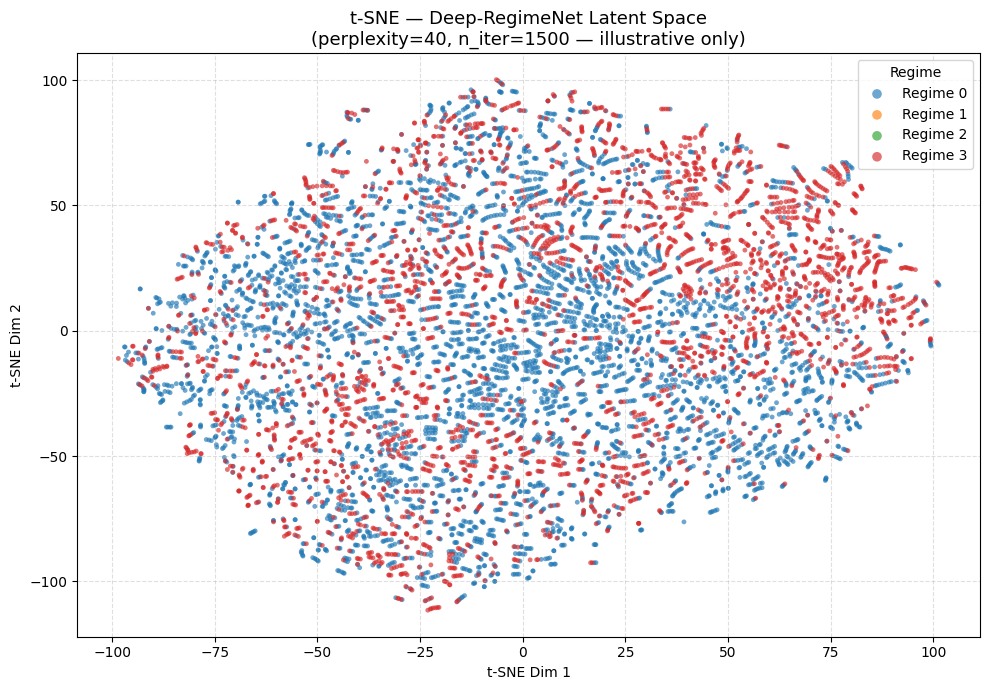

In [39]:
print("Running t-SNE …")
tsne    = TSNE(n_components=2, perplexity=40, n_iter=1500,
               random_state=RANDOM_SEED)
z_tsne  = tsne.fit_transform(drn_latents)

fig, ax = plt.subplots(figsize=(10, 7))
for k in range(BEST_K):
    mask = drn_labels == k
    ax.scatter(z_tsne[mask, 0], z_tsne[mask, 1],
               label=f"Regime {k}", color=palette[k],
               alpha=0.65, s=12, edgecolors="none")
ax.set_title("t-SNE — Deep-RegimeNet Latent Space\n"
             "(perplexity=40, n_iter=1500 — illustrative only)", fontsize=13)
ax.set_xlabel("t-SNE Dim 1"); ax.set_ylabel("t-SNE Dim 2")
ax.legend(title="Regime", markerscale=2)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("tsne_latent_space.png", dpi=130, bbox_inches="tight")
plt.show()

Running UMAP …


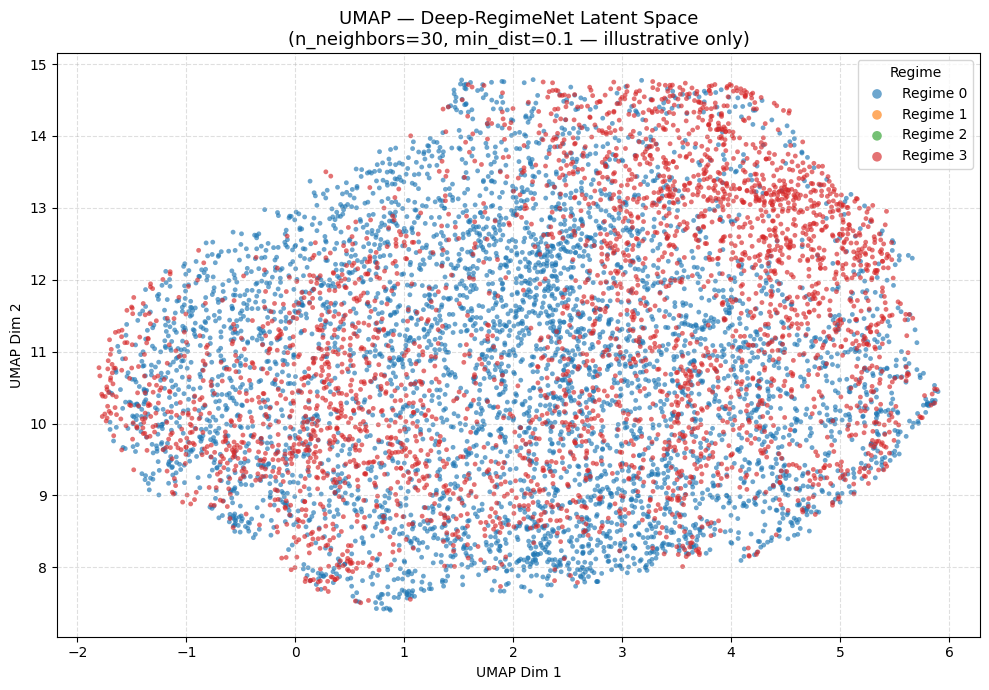

In [40]:
print("Running UMAP …")
reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                    random_state=RANDOM_SEED)
z_umap  = reducer.fit_transform(drn_latents)

fig, ax = plt.subplots(figsize=(10, 7))
for k in range(BEST_K):
    mask = drn_labels == k
    ax.scatter(z_umap[mask, 0], z_umap[mask, 1],
               label=f"Regime {k}", color=palette[k],
               alpha=0.65, s=12, edgecolors="none")
ax.set_title("UMAP — Deep-RegimeNet Latent Space\n"
             "(n_neighbors=30, min_dist=0.1 — illustrative only)", fontsize=13)
ax.set_xlabel("UMAP Dim 1"); ax.set_ylabel("UMAP Dim 2")
ax.legend(title="Regime", markerscale=2)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("umap_latent_space.png", dpi=130, bbox_inches="tight")
plt.show()

## Regime-Conditioned Return Statistics (Primary Economic Endpoint)

In [41]:
TRADING_DAYS  = 252
daily_returns = np.log(raw_data["Close"] / raw_data["Close"].shift(1)).dropna()

def regime_return_stats(labels_series, model_name):
    """
    Primary economic evaluation endpoint (Reviewer §5.2).
    Regime label assigned at window END; returns attributed to t+1 to respect
    temporal alignment and avoid lookahead (Reviewer §5.9).
    """
    # Shift labels forward by 1 day so returns at t are attributed to regime at t-1
    ret   = daily_returns.reindex(labels_series.index)
    reg   = labels_series.shift(1)   # act on signal at next open
    mask  = ret.notna() & reg.notna()
    ret, reg = ret[mask], reg[mask].astype(int)

    print(f"\n  [{model_name}]")
    print(f"  {'Regime':<10} {'N':>6} {'MeanAnn%':>10} {'Vol%':>9} "
          f"{'Skew':>8} {'ExKurt':>8} {'Sharpe':>8}")
    print("  " + "─" * 65)

    stats = {}
    for k in sorted(reg.unique()):
        r = ret[reg == k]
        if len(r) < 10:
            continue
        mean_ann = r.mean()  * TRADING_DAYS * 100
        vol_ann  = r.std()   * np.sqrt(TRADING_DAYS) * 100
        skew     = float(r.skew())
        kurt     = float(r.kurtosis())
        sharpe   = mean_ann / (vol_ann + 1e-9)
        stats[k] = dict(n=len(r), mean_ann=mean_ann, vol_ann=vol_ann,
                        skew=skew, kurt=kurt, sharpe=sharpe)
        print(f"  {k:<10} {len(r):>6} {mean_ann:>10.2f}% {vol_ann:>8.2f}% "
              f"{skew:>8.3f} {kurt:>8.3f} {sharpe:>8.3f}")
    return stats


drn_stats = regime_return_stats(regime_series, "DeepRegimeNet")
ae_stats  = regime_return_stats(
    pd.Series(ae_labels, index=window_dates, name="regime"), "Seq AE + KMeans")
hmm_stats = regime_return_stats(
    pd.Series(hmm_labels, index=window_dates, name="regime"), "Gaussian HMM")
naive_stats = regime_return_stats(
    pd.Series(quantile_labels.astype(int), index=window_dates, name="regime"),
    "Naïve Vol Quantile")


  [DeepRegimeNet]
  Regime          N   MeanAnn%      Vol%     Skew   ExKurt   Sharpe
  ─────────────────────────────────────────────────────────────────
  0            4737       8.28%    17.89%   -0.708   10.158    0.463
  3            3278       8.78%    19.79%   -0.012   10.775    0.444

  [Seq AE + KMeans]
  Regime          N   MeanAnn%      Vol%     Skew   ExKurt   Sharpe
  ─────────────────────────────────────────────────────────────────
  0            2104      11.45%    18.30%   -0.640   13.870    0.626
  1            1688       7.84%    20.25%   -0.834    9.659    0.387
  2            2356       7.85%    16.93%   -0.033    6.845    0.464
  3            1867       6.52%    19.75%    0.059   10.583    0.330

  [Gaussian HMM]
  Regime          N   MeanAnn%      Vol%     Skew   ExKurt   Sharpe
  ─────────────────────────────────────────────────────────────────
  0            1497      12.50%     9.32%   -1.106    5.418    1.341
  1            2599      18.70%    16.03%   -0.347 

## Regime-Switching Strategy vs Buy-and-Hold (Primary Economic Endpoint)

In [42]:
def compute_strategy(labels_series, ret_series, model_name):
    """
    Regime-switching strategy: stay invested except in the worst-Sharpe regime.
    Regime identified at window END; position entered at t+1 open (§5.9).
    Returns strategy cumulative return series and performance metrics.
    """
    reg = labels_series.shift(1)   # signal at t, trade at t+1
    ret = ret_series.reindex(reg.index)
    mask = ret.notna() & reg.notna()
    ret, reg = ret[mask], reg[mask].astype(int)

    # Identify worst regime by mean annualised return (on full sample)
    regime_means = {k: ret[reg == k].mean() * TRADING_DAYS
                    for k in reg.unique() if (reg == k).sum() > 5}
    if not regime_means:
        return pd.Series(dtype=float), {}

    worst = min(regime_means, key=regime_means.get)
    invested  = (reg != worst).astype(float)
    strat_ret = ret * invested
    bh_ret    = ret.copy()
    cum_strat = (1 + strat_ret).cumprod()
    cum_bh    = (1 + bh_ret).cumprod()

    def sharpe(r):
        return r.mean() / (r.std() + 1e-9) * np.sqrt(TRADING_DAYS)

    def max_dd(cum):
        return ((cum - cum.cummax()) / (cum.cummax() + 1e-9)).min()

    def sortino(r):
        downside = r[r < 0].std() + 1e-9
        return r.mean() / downside * np.sqrt(TRADING_DAYS)

    def calmar(r, cum):
        ann = cum.iloc[-1] ** (TRADING_DAYS / len(r)) - 1
        return ann / (abs(max_dd(cum)) + 1e-9)

    perf = {
        "Annualised Sharpe":  sharpe(strat_ret),
        "Sortino Ratio":      sortino(strat_ret),
        "Max Drawdown (%)":   max_dd(cum_strat) * 100,
        "Calmar Ratio":       calmar(strat_ret, cum_strat),
        "Total Return (%)":   (cum_strat.iloc[-1] - 1) * 100,
        "Worst regime exited": worst,
        "BH Sharpe":          sharpe(bh_ret),
        "BH Sortino":         sortino(bh_ret),
        "BH Max DD (%)":      max_dd(cum_bh) * 100,
        "BH Total Ret (%)":   (cum_bh.iloc[-1] - 1) * 100,
    }
    return cum_strat, perf


ret_series_full = daily_returns.reindex(window_dates).dropna()

cum_drn,   perf_drn   = compute_strategy(regime_series, ret_series_full, "DeepRegimeNet")
cum_ae,    perf_ae    = compute_strategy(
    pd.Series(ae_labels, index=window_dates),    ret_series_full, "Seq AE + KMeans")
cum_hmm,   perf_hmm   = compute_strategy(
    pd.Series(hmm_labels, index=window_dates),   ret_series_full, "Gaussian HMM")
cum_naive, perf_naive = compute_strategy(
    pd.Series(quantile_labels.astype(int), index=window_dates), ret_series_full,
    "Naïve Vol Quantile")

print("\n" + "═" * 70)
print("  STRATEGY PERFORMANCE (PRIMARY ECONOMIC ENDPOINT — Reviewer §5.2)")
print("═" * 70)
print(f"  {'Metric':<28} {'DRN':>10} {'Seq AE':>10} {'HMM':>10} {'Naïve':>10} {'B&H':>10}")
print("  " + "─" * 70)
for metric in ["Annualised Sharpe", "Sortino Ratio",
               "Max Drawdown (%)", "Calmar Ratio", "Total Return (%)"]:
    bh_key = {"Annualised Sharpe": "BH Sharpe",
               "Sortino Ratio":    "BH Sortino",
               "Max Drawdown (%)": "BH Max DD (%)",
               "Calmar Ratio":     "BH Max DD (%)",
               "Total Return (%)": "BH Total Ret (%)"}
    bh_val = perf_drn.get(bh_key.get(metric, ""), np.nan)
    print(f"  {metric:<28} "
          f"{perf_drn.get(metric, np.nan):>10.3f} "
          f"{perf_ae.get(metric, np.nan):>10.3f} "
          f"{perf_hmm.get(metric, np.nan):>10.3f} "
          f"{perf_naive.get(metric, np.nan):>10.3f} "
          f"{bh_val:>10.3f}")
print("═" * 70)


══════════════════════════════════════════════════════════════════════
  STRATEGY PERFORMANCE (PRIMARY ECONOMIC ENDPOINT — Reviewer §5.2)
══════════════════════════════════════════════════════════════════════
  Metric                              DRN     Seq AE        HMM      Naïve        B&H
  ──────────────────────────────────────────────────────────────────────
  Annualised Sharpe                 0.284      0.433      0.850      0.425      0.454
  Sortino Ratio                     0.227      0.468      1.020      0.470      0.566
  Max Drawdown (%)                -45.852    -56.313    -43.918    -62.781    -64.333
  Calmar Ratio                      0.062      0.104      0.222      0.099    -64.333
  Total Return (%)                142.772    506.240   1816.995    579.399    750.438
══════════════════════════════════════════════════════════════════════


## Overlap-Corrected Persistence (Reviewer §2.1)

In [43]:
def regime_persistence(labels_series, window_size, model_name):
    """
    Computes mean run length in trading days.
    Also reports overlap-corrected effective sample size to avoid inflating
    persistence estimates from stride-1 overlapping windows (Reviewer §2.1).
    """
    runs, cur_run, cur_lbl = [], 1, labels_series.iloc[0]
    for lbl in labels_series.iloc[1:]:
        if lbl == cur_lbl:
            cur_run += 1
        else:
            runs.append((cur_lbl, cur_run))
            cur_run, cur_lbl = 1, lbl
    runs.append((cur_lbl, cur_run))

    run_df      = pd.DataFrame(runs, columns=["regime", "duration"])
    persistence = run_df.groupby("regime")["duration"].mean()

    n_windows         = len(labels_series)
    n_nonoverlap      = n_windows // window_size
    eff_sample_size   = n_nonoverlap

    print(f"\n  [{model_name}]")
    print(f"  Window size={window_size}  |  "
          f"Total windows={n_windows}  |  "
          f"Non-overlapping (effective n)={eff_sample_size}")
    print(f"  {'Regime':<10} {'Mean Run (days)':>18}")
    for k, p in persistence.items():
        print(f"  {k:<10} {p:>18.1f}")
    print(f"  Note: raw run lengths include window-overlap inflation.")
    print(f"        Effective independent observations ≈ {eff_sample_size}.")
    return persistence


drn_persistence = regime_persistence(regime_series, BEST_WINDOW, "DeepRegimeNet")
ae_persistence  = regime_persistence(
    pd.Series(ae_labels, index=window_dates), BEST_WINDOW, "Seq AE + KMeans")
hmm_persistence = regime_persistence(
    pd.Series(hmm_labels, index=window_dates), BEST_WINDOW, "Gaussian HMM")


  [DeepRegimeNet]
  Window size=20  |  Total windows=8016  |  Non-overlapping (effective n)=400
  Regime        Mean Run (days)
  0                         5.2
  3                         3.6
  Note: raw run lengths include window-overlap inflation.
        Effective independent observations ≈ 400.

  [Seq AE + KMeans]
  Window size=20  |  Total windows=8016  |  Non-overlapping (effective n)=400
  Regime        Mean Run (days)
  0                         4.0
  1                         3.8
  2                         5.0
  3                         3.9
  Note: raw run lengths include window-overlap inflation.
        Effective independent observations ≈ 400.

  [Gaussian HMM]
  Window size=20  |  Total windows=8016  |  Non-overlapping (effective n)=400
  Regime        Mean Run (days)
  0                        27.2
  1                        20.5
  2                        14.5
  3                        19.9
  Note: raw run lengths include window-overlap inflation.
        Effective 

## Regime Transition Matrix

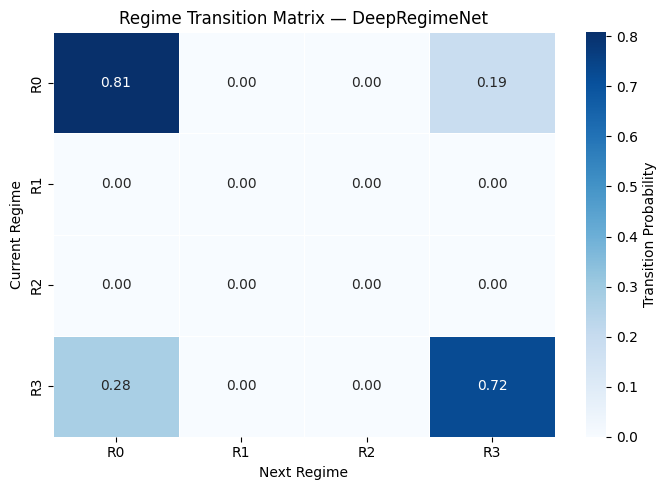

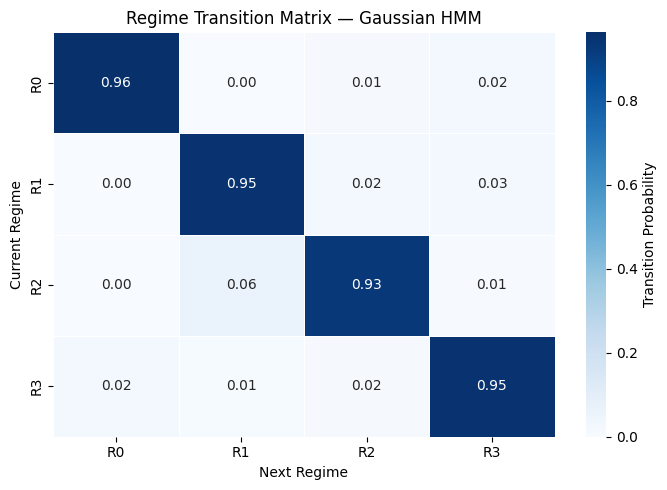

In [44]:
def plot_transition_matrix(labels_series, model_name, n_k):
    la    = labels_series.values
    T     = np.zeros((n_k, n_k))
    for t in range(len(la) - 1):
        T[la[t], la[t + 1]] += 1
    T_norm = T / (T.sum(axis=1, keepdims=True) + 1e-9)

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(T_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=[f"R{k}" for k in range(n_k)],
                yticklabels=[f"R{k}" for k in range(n_k)],
                linewidths=0.5,
                cbar_kws={"label": "Transition Probability"})
    ax.set_title(f"Regime Transition Matrix — {model_name}", fontsize=12)
    ax.set_xlabel("Next Regime"); ax.set_ylabel("Current Regime")
    plt.tight_layout()
    plt.savefig(f"transition_matrix_{model_name.replace(' ', '_')}.png",
                dpi=130, bbox_inches="tight")
    plt.show()
    return T_norm


T_drn = plot_transition_matrix(regime_series, "DeepRegimeNet", BEST_K)
T_hmm = plot_transition_matrix(
    pd.Series(hmm_labels, index=window_dates), "Gaussian HMM", BEST_K)

## Regime Overlay on S&P 500 Price History

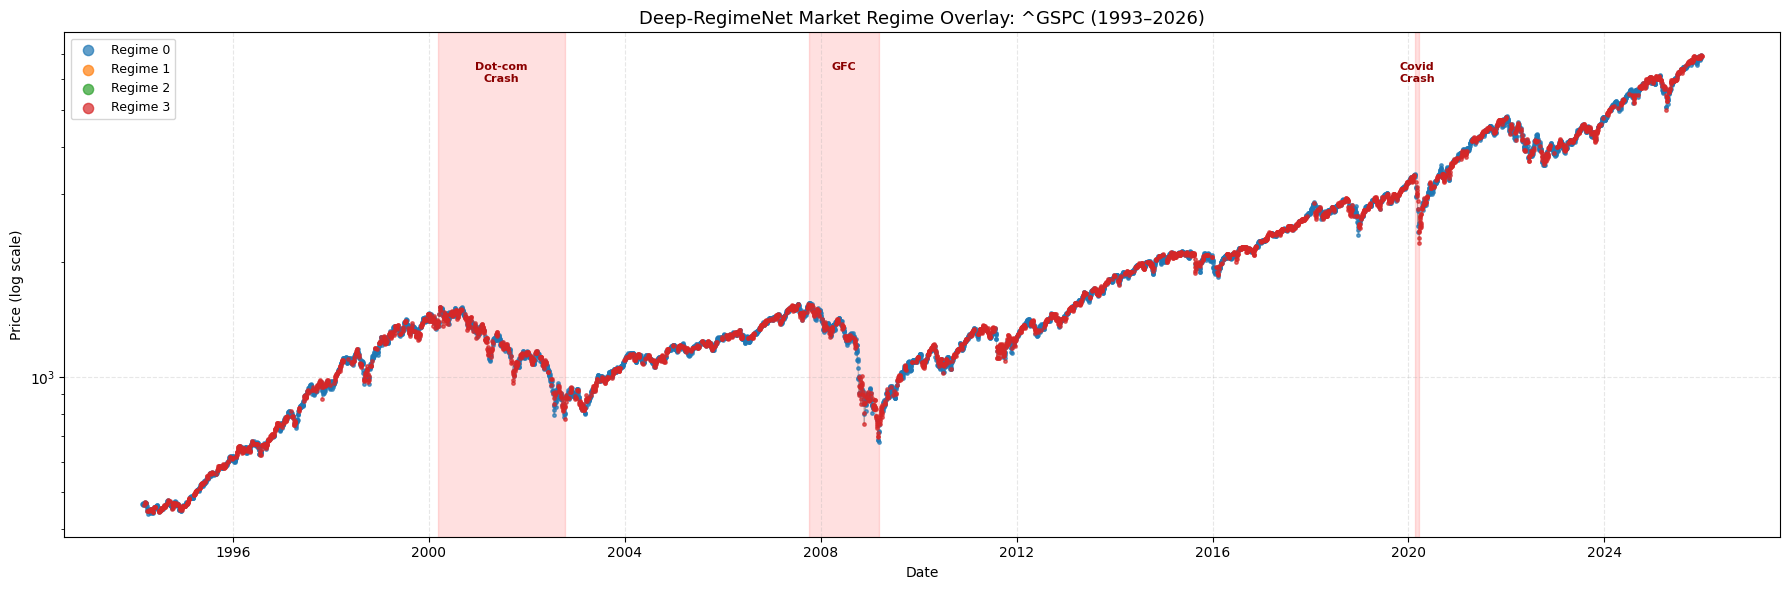

In [45]:
KNOWN_EVENTS = {
    "Dot-com\nCrash": ("2000-03-10", "2002-10-09"),
    "GFC":            ("2007-10-09", "2009-03-09"),
    "Covid\nCrash":   ("2020-02-19", "2020-03-23"),
}

fig, ax = plt.subplots(figsize=(18, 6))
for k in range(BEST_K):
    mask = regime_series == k
    ax.scatter(regime_series.index[mask], close_prices[mask],
               s=6, color=palette[k], label=f"Regime {k}", alpha=0.7, zorder=3)
ax.plot(close_prices.index, close_prices.values,
        color="black", linewidth=0.6, alpha=0.3, zorder=2)
ymax = close_prices.max()
for label, (s, e) in KNOWN_EVENTS.items():
    ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.12, color="red", zorder=1)
    mid = pd.Timestamp(s) + (pd.Timestamp(e) - pd.Timestamp(s)) / 2
    ax.text(mid, ymax * 0.96, label, ha="center", va="top",
            fontsize=8, color="darkred", fontweight="bold")
ax.set_yscale("log")
ax.set_title(f"Deep-RegimeNet Market Regime Overlay: {TICKER} "
             f"({START_DATE[:4]}–{END_DATE[:4]})", fontsize=13)
ax.set_ylabel("Price (log scale)"); ax.set_xlabel("Date")
ax.legend(loc="upper left", markerscale=3, fontsize=9)
ax.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig("regime_overlay_drn.png", dpi=130, bbox_inches="tight")
plt.show()

## Concordance with Known Historical Events (Primary Economic Endpoint)

In [46]:
events_extended = {
    "Dot-com Crash":         ("2000-03-10", "2002-10-09"),
    "GFC":                   ("2007-10-09", "2009-03-09"),
    "Eurozone Crisis":       ("2011-07-01", "2011-10-04"),
    "2015-16 Selloff":       ("2015-08-01", "2016-02-11"),
    "Covid Crash":           ("2020-02-19", "2020-03-23"),
    "Post-GFC Bull Market":  ("2009-03-10", "2020-02-18"),
    "Post-Covid Bull Market":("2020-03-24", "2022-01-03"),
}

def concordance_table(labels_s, model_name):
    """
    Concordance measured as dominant-regime purity within each event window.
    Pre-specified event windows defined before model training (Reviewer §8).
    """
    print(f"\n  [{model_name}]")
    print(f"  {'Event':<28} {'Period':<22} {'Dom.Regime':>12} {'Purity%':>9}")
    print("  " + "─" * 73)
    purities = []
    for evt, (s, e) in events_extended.items():
        mask = (labels_s.index >= s) & (labels_s.index <= e)
        if mask.sum() == 0:
            continue
        ev_labs  = labels_s[mask]
        dominant = int(ev_labs.mode()[0])
        purity   = (ev_labs == dominant).mean() * 100
        purities.append(purity)
        print(f"  {evt:<28}{s[:7]} → {e[:7]}   Regime {dominant}  {purity:>6.1f}%")
    print(f"  Mean purity across events: {np.mean(purities):.1f}%")
    return purities


print("=" * 78)
print("  REGIME CONCORDANCE WITH KNOWN MARKET EVENTS (PRIMARY ECONOMIC ENDPOINT)")
print("=" * 78)
concordance_table(regime_series, "DeepRegimeNet")
concordance_table(pd.Series(ae_labels, index=window_dates), "Seq AE + KMeans")
concordance_table(pd.Series(hmm_labels, index=window_dates), "Gaussian HMM")
concordance_table(pd.Series(quantile_labels.astype(int), index=window_dates),
                  "Naïve Vol Quantile")
print("=" * 78)

  REGIME CONCORDANCE WITH KNOWN MARKET EVENTS (PRIMARY ECONOMIC ENDPOINT)

  [DeepRegimeNet]
  Event                        Period                   Dom.Regime   Purity%
  ─────────────────────────────────────────────────────────────────────────
  Dot-com Crash               2000-03 → 2002-10   Regime 0    57.3%
  GFC                         2007-10 → 2009-03   Regime 0    60.1%
  Eurozone Crisis             2011-07 → 2011-10   Regime 3    68.2%
  2015-16 Selloff             2015-08 → 2016-02   Regime 0    63.4%
  Covid Crash                 2020-02 → 2020-03   Regime 0    50.0%
  Post-GFC Bull Market        2009-03 → 2020-02   Regime 0    55.2%
  Post-Covid Bull Market      2020-03 → 2022-01   Regime 0    58.2%
  Mean purity across events: 58.9%

  [Seq AE + KMeans]
  Event                        Period                   Dom.Regime   Purity%
  ─────────────────────────────────────────────────────────────────────────
  Dot-com Crash               2000-03 → 2002-10   Regime 2    27.8%
 

##